In [1]:
from random_measurement import generate_povm_set_case_1,generate_povm_set_case_2
from blended_measurement import blended_measurement
from qiskit import  execute, BasicAer
import numpy as np
import matplotlib.pyplot as plt
import random
import circuit as cir


%qiskit_version_table


ImportError: cannot import name 'execute' from 'qiskit' (/home/jason/Documents/random_measurement/density/lib/python3.10/site-packages/qiskit/__init__.py)

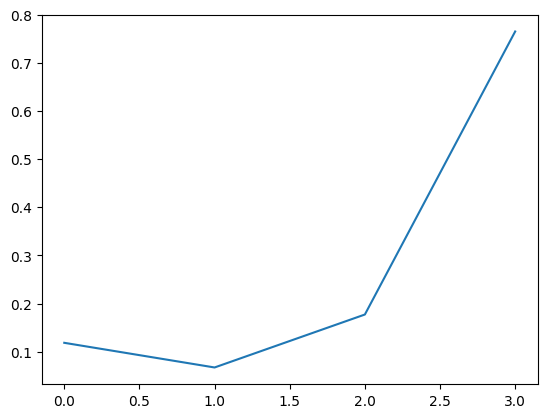

/tmp/ipykernel_7732/2563070705.py:40: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  result = execute(qc, backend, shots=num_shot).result()


{'0': 12568, '1': 3816}


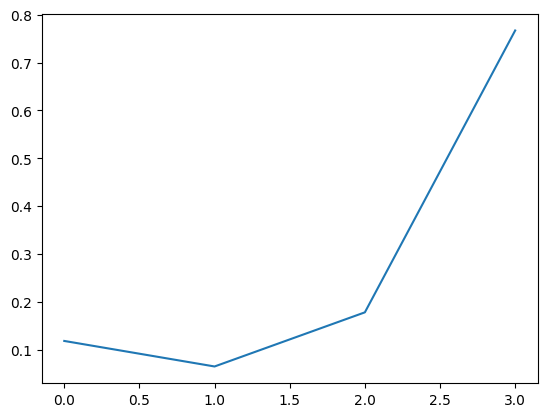

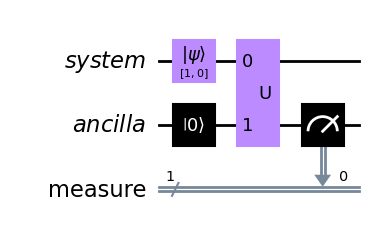

In [ ]:

d = 2  # Dimension
m = 4 # Number of POVM elements

################### generate the povm measurement sets ##################################


povm_set_case_1 = generate_povm_set_case_1(d, m)
povm_set_case_2 = generate_povm_set_case_2(d, m)


################### show the povm set #################################################
povm_set_case=povm_set_case_1
pro=[]
# for item in povm_set_case:
#     eigenval,_=np.linalg.eigh(item)
#     print(eigenval)
roh_0=np.array([[1,0],[0,0]])
for item in povm_set_case:
    pro.append(np.trace(item@roh_0))
    
plt.plot(range(0,m),pro)
plt.show()


################# construct the quantum circuit #################################################

#initial state
num_shot=16384
state=np.array([[1,0]])
state = state/np.linalg.norm(state)
result_y=[]
for item in povm_set_case:
    povm=[]
    povm.append(item)
    inverse=np.eye(d)-item
    povm.append(inverse)
    qc=cir.construct_quantum_circuit(povm,state)

    backend = BasicAer.get_backend('qasm_simulator')
    result = execute(qc, backend, shots=num_shot).result()
    counts = result.get_counts(qc)
    result_y.append(counts['0'])

print(counts)
result_y=[item/num_shot for item in result_y]
plt.plot(range(0,m),result_y)
plt.show()
qc.draw('mpl') #always be put at the final line


{'000': 14650, '011': 463, '001': 498, '100': 316, '010': 457}


/tmp/ipykernel_7732/4209742612.py:15: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  result = execute(qc, backend, shots=num_shot).result()


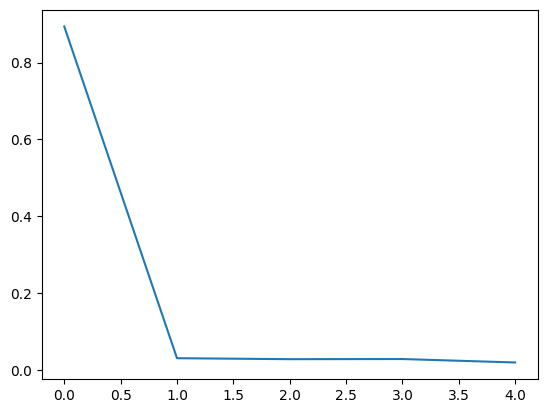

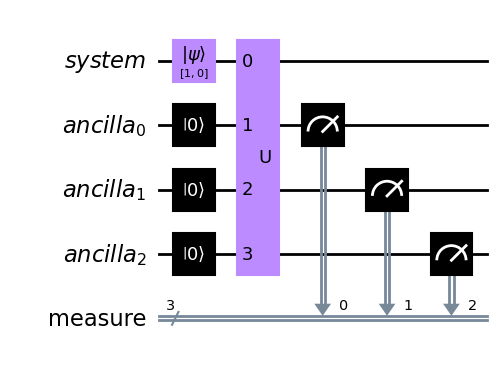

In [ ]:
################## generate blended measurement sets #############################################

blended_case_1=blended_measurement(povm_set_case_1,d,m)
blended_case_2=blended_measurement(povm_set_case_2,d,m)

blended_set=blended_case_2

blended_set=[ item@item.T.conj() for item in blended_set]

# print(sum(blended_set))

qc=cir.construct_quantum_circuit(blended_set,state)

backend = BasicAer.get_backend('qasm_simulator')
result = execute(qc, backend, shots=num_shot).result()
counts = result.get_counts(qc)
print(counts)
result_y=[]

for item in sorted(counts.keys()):
    result_y.append(counts[item]/num_shot)


plt.plot(range(0,m+1),result_y)
plt.show()
qc.draw('mpl') #always be put at the final line

In [ ]:
############### Blend Measurement impletement #########################
num_shot=1
implete_times=10

qc=cir.construct_quantum_circuit(blended_set,state)
qc.save_statevector()
for _ in range(implete_times):
    backend = BasicAer.get_backend('qasm_simulator')
    result = execute(qc, backend, shots=num_shot).result()
    counts = result.get_counts(qc)
    
    print(counts)


AttributeError: 'QuantumCircuit' object has no attribute 'save_statevector'